# Avansert Lydprosessering: Onsets, Sustain og Pitch

Denne notebooken bygger videre på mel-spektrogrammer for å trekke ut spesifikke trekk (features) som direkte mapper til variablene i den felles sannheten ($D$).

Vi vil fokusere på:
1. **Harmonisk/Perkusiv Separasjon (HPSS):** For å skille vedvarende toner ($D_{sustain}$) fra anslag ($D_{onset}$).
2. **Onset Detection:** For å bygge en presis tidslinje for noteanslag.
3. **Kromagram (Chroma):** For å estimere tonehøyde-klasser ($p$) og harmonisk innhold.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

plt.rcParams['figure.figsize'] = (14, 6)

## 1. Laster inn lyd
Igjen bruker vi et eksempel fra librosa (f.eks. 'nutcracker' for litt mer kompleks musikk enn en enkelt trompet).

In [2]:
# Vi bruker utdrag av Nøtteknekkeren for å ha litt orkestral fylde
y, sr = librosa.load(librosa.ex('nutcracker'), duration=10.0)

# Grunnleggende Mel-spektrogram for referanse
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

## 2. Harmonisk / Perkusiv Separasjon (HPSS)

HPSS utnytter at harmoniske lyder (toner, $D_{sustain}$) danner horisontale strukturer i spektrogrammet, mens perkusjon og onsets ($D_{onset}$) danner vertikale strukturer.
Ved å skille disse kan vi filtrere informasjonen før vi sender den til domenet $D$.

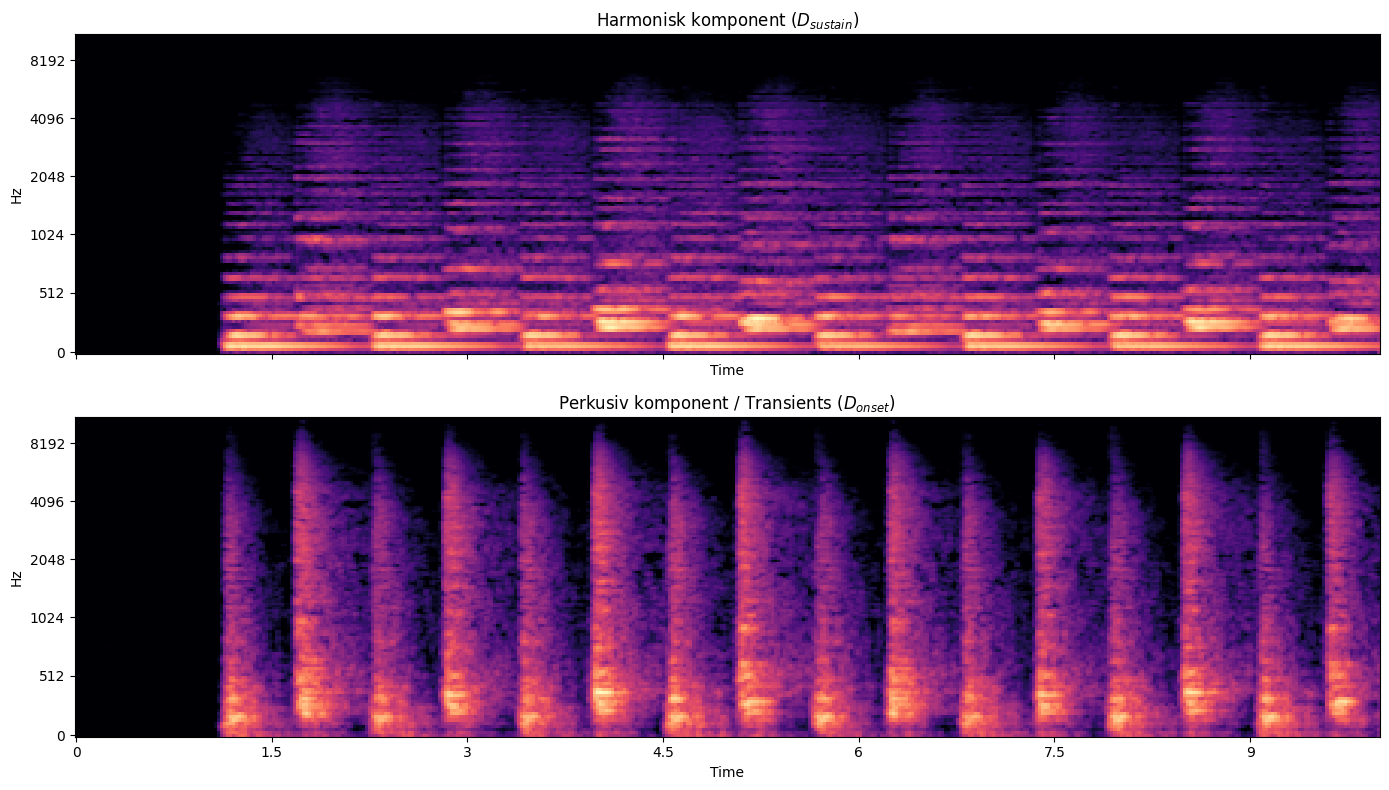

In [3]:
# Utfører separasjon på spektrumet
y_harmonic, y_percussive = librosa.effects.hpss(y)

# Beregner spektrogram for begge delene
S_harm = librosa.feature.melspectrogram(y=y_harmonic, sr=sr, n_mels=128)
S_perc = librosa.feature.melspectrogram(y=y_percussive, sr=sr, n_mels=128)

S_harm_dB = librosa.power_to_db(S_harm, ref=np.max)
S_perc_dB = librosa.power_to_db(S_perc, ref=np.max)

fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True, figsize=(14, 8))
librosa.display.specshow(S_harm_dB, x_axis='time', y_axis='mel', ax=ax[0])
ax[0].set(title='Harmonisk komponent ($D_{sustain}$)')

librosa.display.specshow(S_perc_dB, x_axis='time', y_axis='mel', ax=ax[1])
ax[1].set(title='Perkusiv komponent / Transients ($D_{onset}$)')
plt.tight_layout()

## 3. Onset Detection

Vi kan beregne en *onset strength envelope* for å finne tidspunktene der notene slås an. Denne kurven gir et estimat for aktiveringen av $D_{onset}$ over tid.

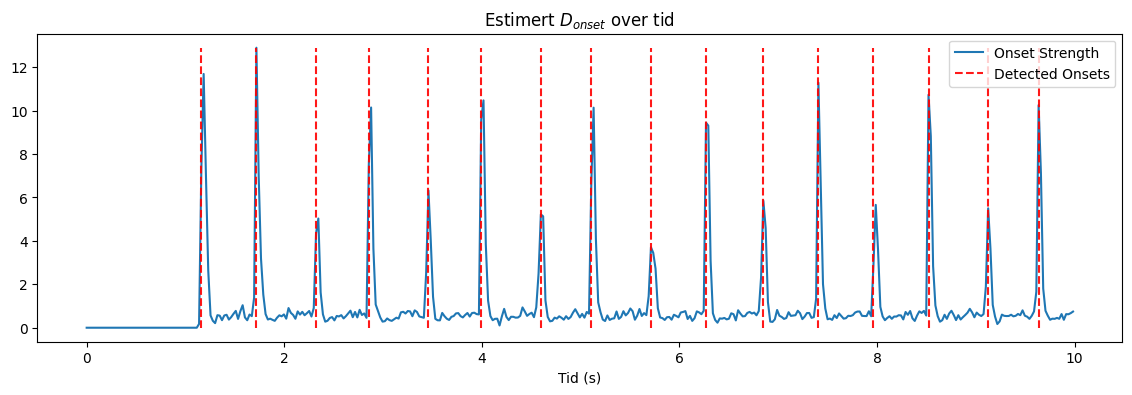

In [4]:
# Beregner 'onset envelope' - hvor mye energien øker
onset_env = librosa.onset.onset_strength(y=y, sr=sr)
times = librosa.times_like(onset_env, sr=sr)

# Finner de faktiske toppene (onsets)
onsets = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr)

plt.figure(figsize=(14, 4))
plt.plot(times, onset_env, label='Onset Strength')
plt.vlines(times[onsets], 0, onset_env.max(), color='r', alpha=0.9, linestyle='--', label='Detected Onsets')
plt.title('Estimert $D_{onset}$ over tid')
plt.xlabel('Tid (s)')
plt.legend()
plt.show()

## 4. Kromagram (Pitch Classes)

Et kromagram (Chromagram) grupperer all energi over oktaver ned til de 12 toneklassene (C, C#, D, etc.). 
Dette er svært nyttig for $D_{sustain}$ fordi det gir oss en direkte representasjon av *hvilken* tone som klinger, 
uavhengig av hvilken oktav den befinner seg i. Det hjelper med å slå sammen horisontal evidens fra note-bildet.

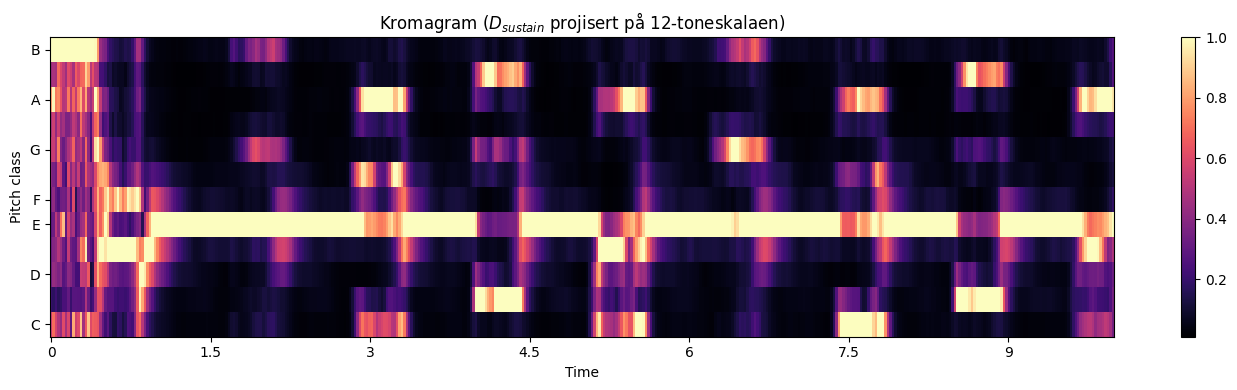

In [5]:
# Beregner kromagram fra den harmoniske delen (for å unngå støy fra perkusjon)
chroma = librosa.feature.chroma_cqt(y=y_harmonic, sr=sr)

plt.figure(figsize=(14, 4))
librosa.display.specshow(chroma, y_axis='chroma', x_axis='time')
plt.colorbar()
plt.title('Kromagram ($D_{sustain}$ projisert på 12-toneskalaen)')
plt.tight_layout()
plt.show()

## Konklusjon og Veien Videre for OMR

Ved å bruke metodene over har vi nå byggeklossene for auditive projeksjoner i Bayesian Sensor Fusion:
1. **Onset Detect / Percussive part** -> Informerer når en vertikal linje (onset) skjer ($D_{onset}(t)$).
2. **Harmonic part / Chroma** -> Informerer hvilke tonetrinn og hvor lenge de klinger ($D_{sustain}(t, p)$).

Neste steg er å samkjøre denne tid/pitch-matrisen med rutenettet (posisjons-indexene) som vi får fra bildegjenkjenningen.